# **Program 1**
Q. Explore pre-trained word vectors. Explore word relationships using vector arithmetic. Perform arithmetic operations and analyze results.

In [1]:
#!pip install gensim
import gensim.downloader as api

m = api.load("word2vec-google-news-300")

print("Similar to king:", m.most_similar("king", topn=5))

print("king - man + woman =")
print(m.most_similar(positive=["king","woman"], negative=["man"], topn=5))
#Time: 47.9s

Similar to king: [('kings', 0.7138044834136963), ('queen', 0.6510957479476929), ('monarch', 0.6413194537162781), ('crown_prince', 0.6204219460487366), ('prince', 0.6159994602203369)]
king - man + woman =
[('queen', 0.7118191123008728), ('monarch', 0.6189674735069275), ('princess', 0.5902430415153503), ('crown_prince', 0.5499458909034729), ('prince', 0.5377322435379028)]


# **Program 2**
Q. Use dimensionality reduction (e.g., PCA or t-SNE) to visualize word
embeddings for Q 1. Select 10 words from a specific domain (e.g., sports,
technology) and visualize their embeddings. Analyze clusters and relationships.
Generate contextually rich outputs using embeddings. Write a program to
generate 5 semantically similar words for a given input.


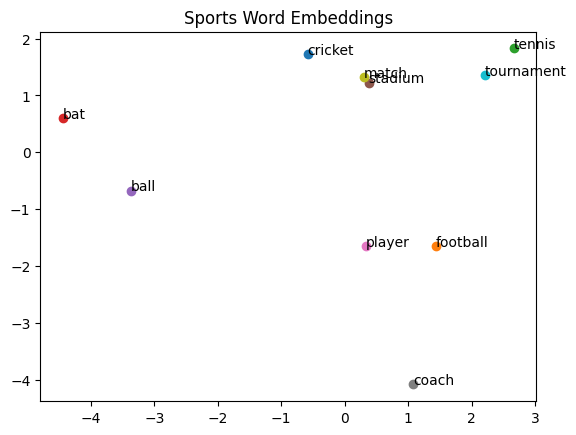

semantically similar words:
 [('kick', 0.7723649740219116), ('throw', 0.7400174736976624), ('balls', 0.7349199056625366), ('off', 0.7285564541816711), ('pitch', 0.7162728905677795)]


In [9]:
#!pip install gensim scikit-learn matplotlib

import gensim.downloader as api
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

model = api.load("glove-wiki-gigaword-100")

words = ["cricket","football","tennis","bat","ball",
         "stadium","player","coach","match","tournament"]

vectors = [model[w] for w in words]

pca = PCA(n_components=2)
points = pca.fit_transform(vectors)

for i, w in enumerate(words):
    plt.scatter(points[i,0], points[i,1])
    plt.text(points[i,0], points[i,1], w)
plt.title("Sports Word Embeddings")
plt.show()

# word = input("Enter word: ")
word="ball"
print("semantically similar words:\n", model.most_similar(word, topn=5))
#Time: 39.3s

# **Program 3**
Q. Train a custom Word2Vec model on a small dataset. Train embeddings on a
domain-specific corpus (e.g., legal, medical) and analyze how embeddings
capture domain-specific semantics.
Program

treats : 0.12
surgeon : 0.08
hospital : 0.07
patient : 0.04
prescribes : 0.02


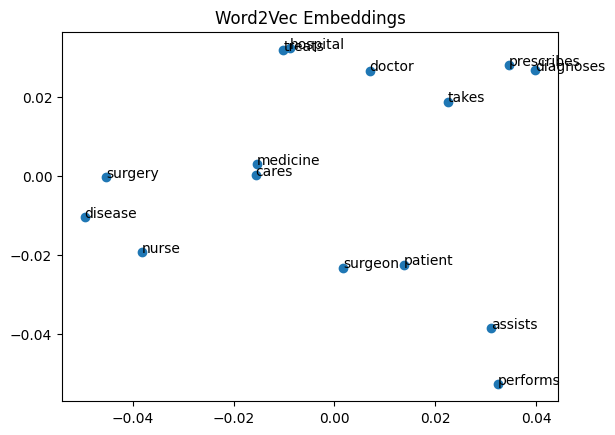

In [13]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

sentences = [
    ["doctor","treats","patient"],
    ["nurse","assists","doctor"],
    ["patient","takes","medicine"],
    ["surgeon","performs","surgery"],
    ["doctor","diagnoses","disease"],
    ["nurse","cares","patient"],
    ["hospital","treats","patient"],
    ["doctor","prescribes","medicine"]
]

model = Word2Vec(sentences, vector_size=50, window=3, min_count=1)

for w, s in model.wv.most_similar("doctor", topn=5):
    print(f"{w} : {s:.2f}")

words = list(model.wv.index_to_key)
points = PCA(n_components=2).fit_transform(model.wv[words])

plt.scatter(points[:,0], points[:,1])

for i, w in enumerate(words):
    plt.text(points[i,0], points[i,1], w)

plt.title("Word2Vec Embeddings")
plt.show()
#Time: 0.1s

# **Program 4**
Q. Use word embeddings to improve prompts for Generative AI model. Retrieve
similar words using word embeddings. Use the similar words to enrich a GenAI
prompt. Use the AI model to generate responses for the original and enriched
prompts. Compare the outputs in terms of detail and relevance.
Program

In [4]:
#!pip install gensim transformers torch

import gensim.downloader as api
from transformers import pipeline

model = api.load("glove-wiki-gigaword-100")
gen = pipeline("text-generation", model="gpt2")

prompt = "Explain cricket"

print("Original Output:\n")
print(gen(prompt, max_length=50)[0]["generated_text"])

words = [w for w, _ in model.most_similar("cricket", topn=5)]

new_prompt = prompt + " including " + ", ".join(words)

print("\nEnriched Output:\n")
print(gen(new_prompt, max_length=80)[0]["generated_text"])
#Time: 49.4s

c:\Users\JHASHANK\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


Original Output:



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Explain cricket as an instrument of control.

I've always said that, when we create cricket, we have to try to make it one which will be useful. And it seems to me that it's a very naive idea that cricket needs

Enriched Output:

Explain cricket including rugby, twenty20, england, indies, cricketers etc.


# **Program 5**
Q. Use word embeddings to create meaningful sentences for creative tasks.
Retrieve similar words for a seed word. Create a sentence or story using these
words as a starting point. Write a program that: Takes a seed word. Generates
similar words. Constructs a short paragraph using these words.
Program

In [5]:
#!pip install gensim transformers torch

import gensim.downloader as api
from transformers import pipeline

model = api.load("glove-wiki-gigaword-100")
gen = pipeline("text-generation", model="gpt2")

#seed = input("Enter seed word: ")
seed="technology"
words = [w for w, _ in model.most_similar(seed, topn=5)]

prompt = f"{seed.capitalize()} is an important concept related to {', '.join(words)}. It"

print("\nSimilar Words:")
print(words)

print("\nGenerated Paragraph:\n")

text = gen(prompt, max_length=80)[0]["generated_text"]

print(text)
#Time: 43.4s

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Similar Words:
['technologies', 'computer', 'tech', 'software', 'systems']

Generated Paragraph:

Technology is an important concept related to technologies, computer, tech, software, systems. It is very important to understand the fundamental difference of the 3D technologies, technology companies, and the 3D space. I will focus on the 4 things that are a big part of computer science and digital science.

Computer science is a large profession and the way it is taught is in 3D printing and


# **Program 6**
Q. Use a pre-trained Hugging Face model to analyze sentiment in text. Assume a
real-world application, Load the sentiment analysis pipeline. Analyze the
sentiment by giving sentences to inp

In [6]:
from transformers import pipeline
model_name = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
sentiment_analyzer = pipeline("sentiment-analysis", model=model_name)
sentences = ["I love how easy this app is to use.","The delivery was late","The movie was terrible"]
for sentence, result in zip(sentences, sentiment_analyzer(sentences)):
    print(f"Text: {sentence}")
    print(f"Sentiment: {result['label']}, Confidence: {result['score']:.4f}\n")
#Time: 1.1s

Device set to use cuda:0


Text: I love how easy this app is to use.
Sentiment: POSITIVE, Confidence: 0.9989

Text: The delivery was late
Sentiment: NEGATIVE, Confidence: 0.9991

Text: The movie was terrible
Sentiment: NEGATIVE, Confidence: 0.9998



# **Program 7**
Q. Summarize long texts using a pre-trained summarization model using Hugging
face model. Load the summarization pipeline. Take a passage as input and obtain
the summarized text.

In [7]:
from transformers import pipeline

summarizer = pipeline("summarization", model="t5-small")

text = """
The explosion of online shopping has transformed commerce.
Consumers now expect fast delivery, transparent reviews,
and personalized recommendations. Retailers invest in
logistics and data to meet these expectations while
balancing cost and sustainability.
"""

summary = summarizer(
    "summarize: " + text,
    max_length=30,
    min_length=10,
    do_sample=False
)[0]["summary_text"]

print(summary)
#Time: 2.6s

Device set to use cuda:0


the explosion of online shopping has transformed commerce . consumers expect fast delivery, transparent reviews and personalized recommendations .


# **Program 8**
Q. Install langchain, cohere (for key), langchain-community. Get the api key( By
logging into Cohere and obtaining the cohere key). Load a text document from
your google drive . Create a prompt template to display the output in a particular
manner.

In [8]:
# pip install langchain langchain-community langchain-cohere requests
import requests
from langchain_core.prompts import PromptTemplate
from langchain_cohere import ChatCohere 
# --- Load document from Google Drive ---
url = "https://drive.google.com/uc?id=1DGVYAgcOz3KZehzj6S4uOcJAGo4oj57G&export=download"
text = requests.get(url).text
# --- Direct API Key (Hardcoded) ---
llm = ChatCohere(cohere_api_key="XQAbXr2w15Qqe0D5Pzwx5hooGkBoXXmrJMMdxuCO",model="command-a-03-2025")
# --- Prompt Template ---
prompt = PromptTemplate(input_variables=["data"],template="Summarize the following document in 5 key points with each point not more that 12 words:\n\n{data}")
# --- Run ---
print(llm.invoke(prompt.format(data=text)).content)
#Time: 4.9s

1. Indian Army, established 1895, is a global leader in military strength.  
2. Defends India's borders, maintains internal peace, embodies "Service Before Self."  
3. Operates in diverse terrains, from Himalayas to Rajasthan deserts.  
4. Proven valor in conflicts, counter-insurgency, and global peacekeeping missions.  
5. Engages in disaster relief, showcasing humanitarian values and national pride.
